Converged after 100 iterations. Optimal parameters: m=7.46, c=49.20


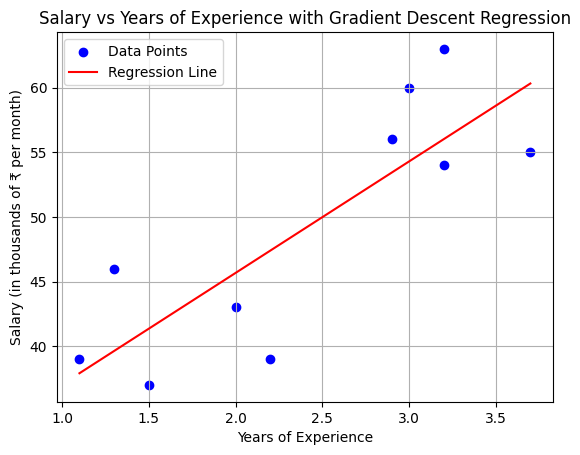

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset: Years of Experience vs Salary (in thousands of ₹ per month)
years_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7])
salary_k = np.array([39, 46, 37, 43, 39, 56, 60, 54, 63, 55])

# Normalize years of experience
years_experience_norm = (years_experience - np.mean(years_experience)) / np.std(years_experience)
cost=[]
# Cost function (Mean Squared Error)
def f(x):
  # x[0] is slope (m), x[1] is intercept (c)
  y_predicted = x[0] * years_experience_norm + x[1]
  return np.mean((y_predicted - salary_k)**2)

# Gradient of the cost function
def grad(x):
  y_predicted = x[0] * years_experience_norm + x[1]

  df_dm = np.mean(2 * (y_predicted - salary_k) * years_experience_norm)

  df_dc = np.mean(2 * (y_predicted - salary_k))
  return np.array([df_dm, df_dc])

# Initialize parameters for gradient descent (slope and intercept)
x = np.array([0.0, 0.0]) # [m, c]

tols = 1e-9
k = 0 # Iteration counter

# Implementation of gradient descent algorithm with backtracking line search
max_iterations = 100

while np.linalg.norm(grad(x)) > tols and k < max_iterations:
  alpha, rho, c_parameter = 0.1, 0.5, 1e-4
  d = -grad(x) 

  # Backtracking line search
  while f(x + alpha * d) > f(x) + c_parameter * alpha * np.dot(grad(x), d):
    alpha = rho * alpha

  x = x + alpha * d # Update parameters
  k += 1
  cost.append(f(x)) # Store the cost at each iteration
print(f"Converged after {k} iterations. Optimal parameters: m={x[0]:.2f}, c={x[1]:.2f}")

# Plotting the results
plt.scatter(years_experience, salary_k, color="blue", label="Data Points")

# Generate points for the regression line
x_line = np.linspace(years_experience.min(), years_experience.max(), 100)
x_line_norm = (x_line - np.mean(years_experience)) / np.std(years_experience)
y_line = x[0] * x_line_norm + x[1]

plt.plot(x_line, y_line, color="red", label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (in thousands of ₹ per month)")
plt.title("Salary vs Years of Experience with Gradient Descent Regression")
plt.legend()
plt.grid(True)
plt.show()


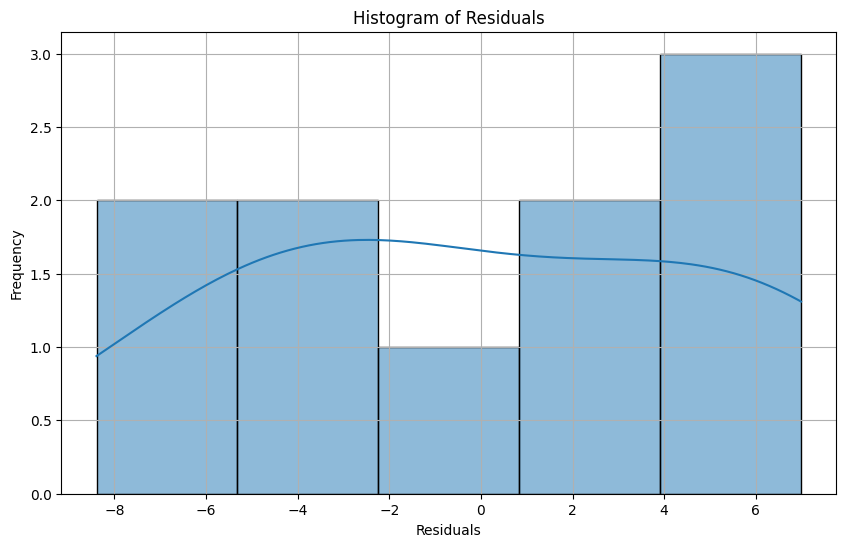

In [16]:
import seaborn as sns
y_predicted = x[0] * years_experience_norm + x[1]
residuals = salary_k - y_predicted

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


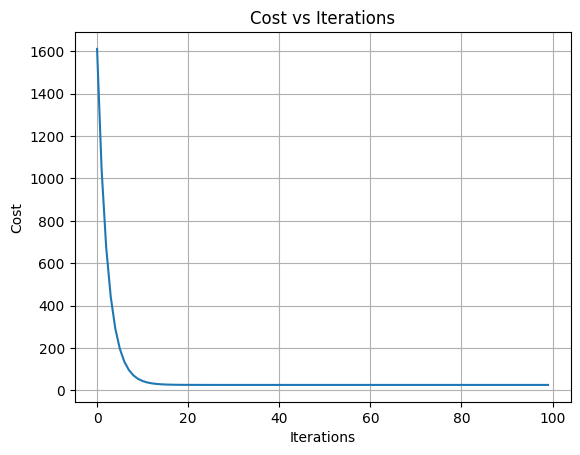

In [18]:
plt.plot(range(len(cost)), cost)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.grid(True)
plt.show()